<a href="https://colab.research.google.com/github/vyasathul17/Machine-Learning/blob/main/PCA%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.tree import DecisionTreeClassifier

# Load Dataset

In [2]:
digits = load_digits()
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

#Train-Test-split

In [3]:
x = digits.data
y = digits.target

In [4]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size  = 0.8,random_state= 42)

In [6]:
x_train.shape

(1437, 64)

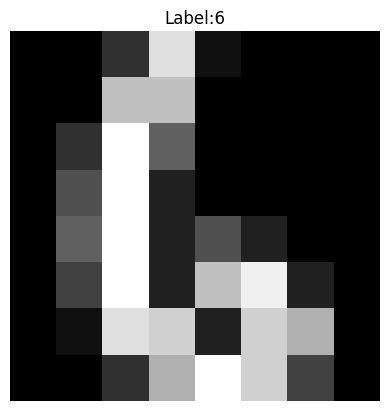

In [8]:
plt.imshow(x_train[0].reshape(8,8),cmap = "gray")
plt.title(f"Label:{y_train[0]}")
plt.axis("off")
plt.show()

In [9]:
y_train[0]

np.int64(6)

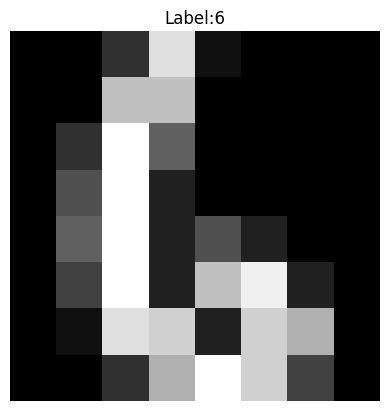

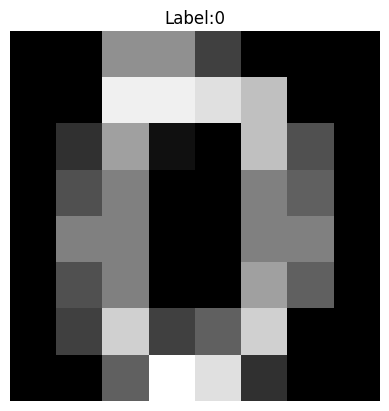

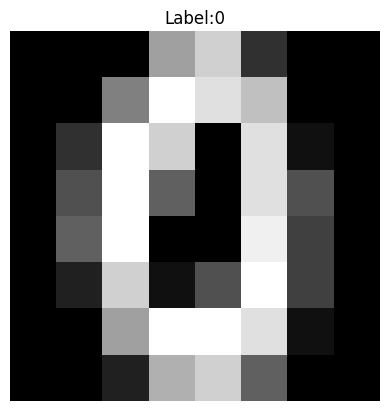

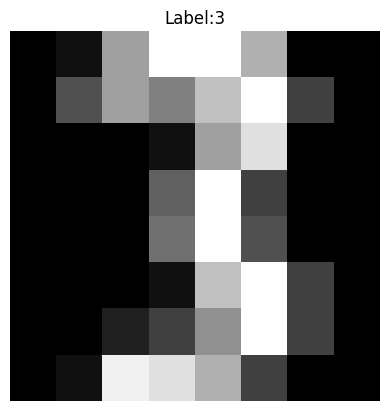

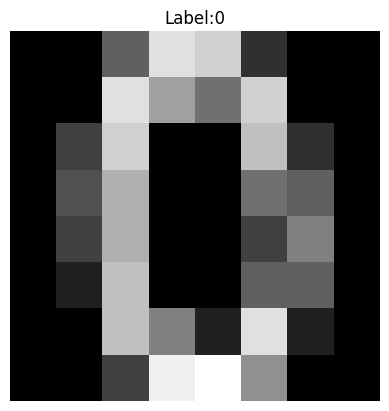

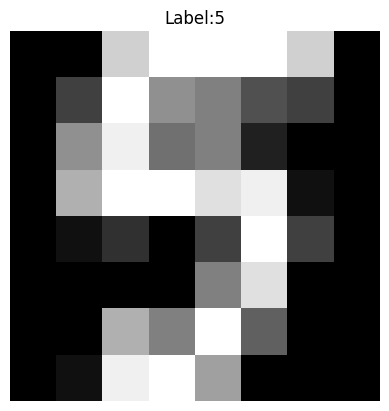

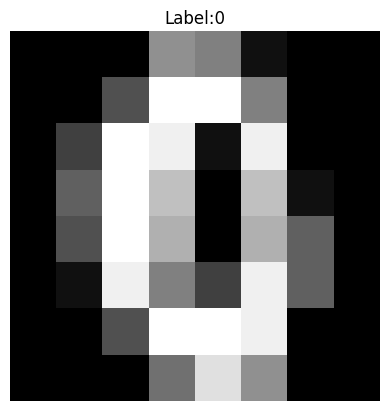

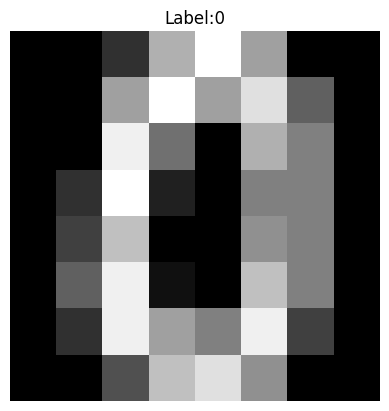

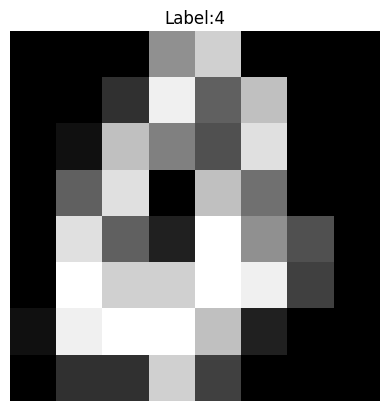

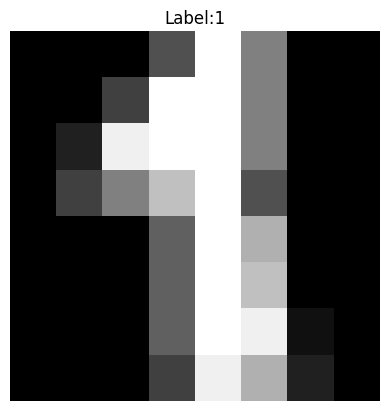

In [10]:
for i in range(10):
  plt.imshow(x_train[i].reshape(8,8),cmap = "gray")
  plt.title(f"Label:{y_train[i]}")
  plt.axis("off")
  plt.show()

In [11]:
x_train.shape

(1437, 64)

#PCA pipeline

In [12]:
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(
    steps = [
        ("scaler",StandardScaler()),
        ("pca",PCA(n_components = 0.95)),
        ("model",LogisticRegression(max_iter = 1000))
    ]
)

#Train Model

In [13]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.95)),
                ('model', LogisticRegression(max_iter=1000))])

#Prediction and Evaluation

In [14]:
pred = pipeline.predict(x_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("\nclassification Report:\n",classification_report(y_test,pred))

Accuracy: 0.9611111111111111

classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      0.96      0.95        28
           2       0.97      0.97      0.97        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.90      0.90      0.90        30
           9       0.95      0.93      0.94        40

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



#Explained variance

“Explained variance ratio tells how much variance each principal component captures, helping us decide how many components to retain while preserving most of the information.”

In [15]:
pca = pipeline.named_steps["pca"]
print("Explained Variance Ratio:\n",pca.explained_variance_ratio_)

Explained Variance Ratio:
 [0.12038006 0.09733098 0.08561821 0.06493777 0.04887914 0.04264048
 0.03949359 0.03349634 0.03023564 0.02931935 0.02772034 0.02544597
 0.02303063 0.02284083 0.02121741 0.01896257 0.01747417 0.01604341
 0.0158501  0.01508824 0.01339746 0.01273262 0.01138241 0.01043294
 0.00985377 0.00937385 0.00853172 0.00836261 0.00797069 0.00757462
 0.007004   0.00690267 0.00642917 0.00612906 0.00574282 0.00537687
 0.00502651 0.00476078 0.0045189  0.00429742]


# Cumulative Variance Plot

“Cumulative variance is the total variance explained by the first N principal components, and it helps us determine how many components are needed to retain most of the data’s information.”

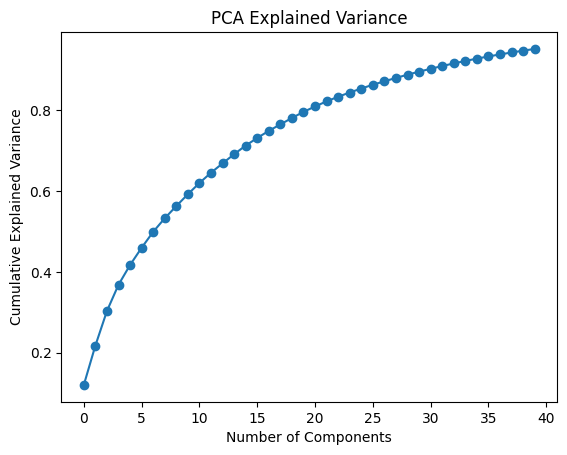

In [16]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cum_var,marker = "o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

#Compare with vs Without PCA

In [17]:
#Without pca

model_no_pca = Pipeline(
    steps = [
        ("scaler",StandardScaler()),
        ("model",LogisticRegression(max_iter = 1000))
    ]
)

model_no_pca.fit(x_train,y_train)
pred_no_pca = model_no_pca.predict(x_test)


#with pca

pred_pca = pred

print("without PCA:",accuracy_score(y_test,pred_no_pca))
print("with PCA:",accuracy_score(y_test,pred_pca))

without PCA: 0.9722222222222222
with PCA: 0.9611111111111111
